In [1]:
#Sentiment_Analysis_project

In [2]:
!pip install wordcloud
!pip install nltk
import nltk
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\jobin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jobin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jobin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jobin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jobin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
import pandas as pd
import numpy as np

import re
import string

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import wordcloud

import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
#Load the dataset

In [5]:
df=pd.read_excel('dataset.xlsx')
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [6]:
#Check the shape of the dataset

In [7]:
df.shape

(1440, 3)

In [8]:
#check the first 5 rows

In [9]:
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [10]:
#check the last 5 rows

In [11]:
df.tail()

,title,rating,body
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."
1439,Beast of the best.,5,The phone is a real beast the battery lasts ea...


In [12]:
#check the dtype of the data

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [14]:
#check the statistical summary of original data

In [15]:
df.describe(include='all')

,title,rating,body
count,1440,1440.000000,1440
unique,1351,NaN,1440
top,Value for money,NaN,Very disappointed with the overall performance...
freq,16,NaN,1
mean,NaN,3.173611,NaN
std,NaN,1.584453,NaN
min,NaN,1.000000,NaN
25%,NaN,1.000000,NaN
50%,NaN,4.000000,NaN
75%,NaN,5.000000,NaN


In [16]:
#check whether there is any missing values in the data

In [17]:
df.isnull().sum()

title     0
rating    0
body      0
dtype: int64

In [18]:
#check whether there is any duplicate values in the data

In [19]:
df.duplicated().sum()

np.int64(0)

There is no duplicate and null values in the dataset

In [20]:
#combine the the columns title and body

In [21]:
df['review_text']=df['title']+' '+df['body']
df.head()

,title,rating,body,review_text
0,Horrible product,1,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Camera quality is not like 48 megapixel Camera...
2,Overall,4,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...


In [22]:
#check the rating contains any other values

In [23]:
df['rating'].unique()

array([1, 3, 4, 5, 2])

In [24]:
#check how many reviews contain the each rating

In [25]:
df['rating'].value_counts().sort_index()

rating
1    386
2    126
3    199
4    310
5    419
Name: count, dtype: int64

In [26]:
#Visualize the rating

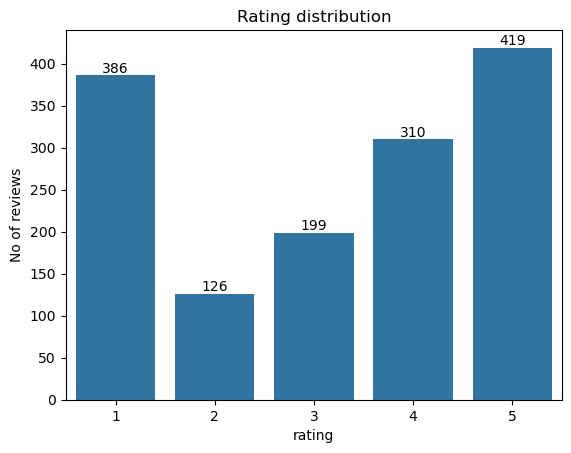

In [27]:
ar=sns.countplot(x='rating',data=df)
ar.bar_label(ar.containers[0],fmt='%d')
plt.title('Rating distribution')
plt.xlabel('rating')
plt.ylabel('No of reviews')
plt.show()

In [28]:
#Based on the rating convert into sentiment 

In [29]:
import numpy as np

conditions=[
    df['rating']>=4,
    df['rating']==3,
    df['rating']<=2
]
choices=['Positive','Neutral','Negative']

df['rating_sentiment']=np.select(conditions,choices,default='unknown')

In [30]:
df.head()

,title,rating,body,review_text,rating_sentiment
0,Horrible product,1,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...,Negative
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Camera quality is not like 48 megapixel Camera...,Neutral
2,Overall,4,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt...",Positive
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...,Negative
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...,Negative


In [31]:
#wordcloud for combined text

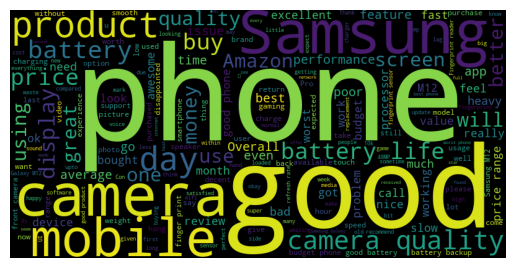

In [32]:
from wordcloud import WordCloud
text=' '.join(df['review_text'])
wordcloud=WordCloud(width=800,height=400).generate(text)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [33]:
#wordclod for positive reviews

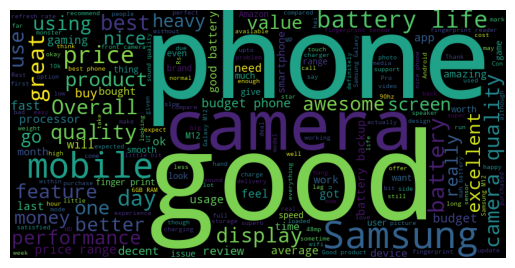

In [34]:
text=' '.join(df[df['rating_sentiment']=='Positive']['review_text'])
wordcloud=WordCloud(width=800,height=400).generate(text)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [35]:
#wordcloud for negative reviews

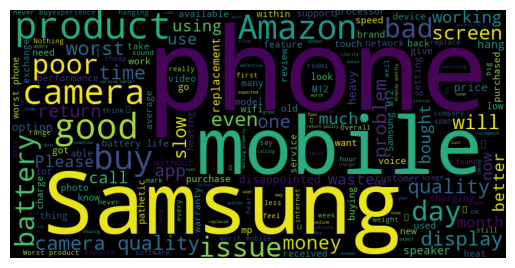

In [36]:
text=' '.join(df[df['rating_sentiment']=='Negative']['review_text'])
wordcloud=WordCloud(width=800,height=400).generate(text)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [37]:
#By using review_text calculate VADER score and VADER sentiment

In [38]:
sia = SentimentIntensityAnalyzer()

# Calculate VADER compound score
df['vader_score'] = df['review_text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Categorize sentiment based on thresholds
df['vader_sentiment'] = df['vader_score'].apply(
    lambda score: 'Positive' if score >= 0.05 else ('Negative' if score <= -0.05 else 'Neutral')
)

In [39]:
df.head()

,title,rating,body,review_text,rating_sentiment,vader_score,vader_sentiment
0,Horrible product,1,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...,Negative,-0.7841,Negative
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Camera quality is not like 48 megapixel Camera...,Neutral,-0.4956,Negative
2,Overall,4,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt...",Positive,0.1027,Positive
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...,Negative,-0.9162,Negative
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...,Negative,-0.8033,Negative


In [40]:
#Rating sentiment distribution

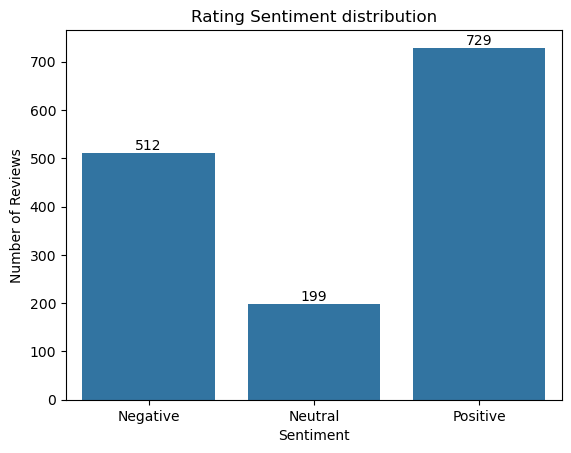

In [41]:
ax=sns.countplot(x='rating_sentiment',data=df)
ax.bar_label(ax.containers[0], fmt='%d')
plt.title('Rating Sentiment distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

In [42]:
#VADER sentiment distribution

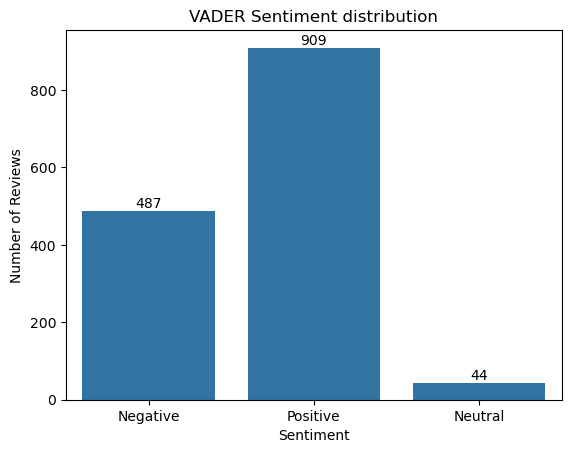

In [43]:
ax=sns.countplot(x='vader_sentiment',data=df)
ax.bar_label(ax.containers[0], fmt='%d')
plt.title('VADER Sentiment distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

In [44]:
#comparision of rating based and VADER based distribution

In [45]:
comparision=pd.crosstab(
    df['rating_sentiment'],
    df['vader_sentiment']
        )
print(comparision)

vader_sentiment   Negative  Neutral  Positive
rating_sentiment                             
Negative               361       21       130
Neutral                 81        6       112
Positive                45       17       667


In [46]:
#visualize the comparision with the help of heat map

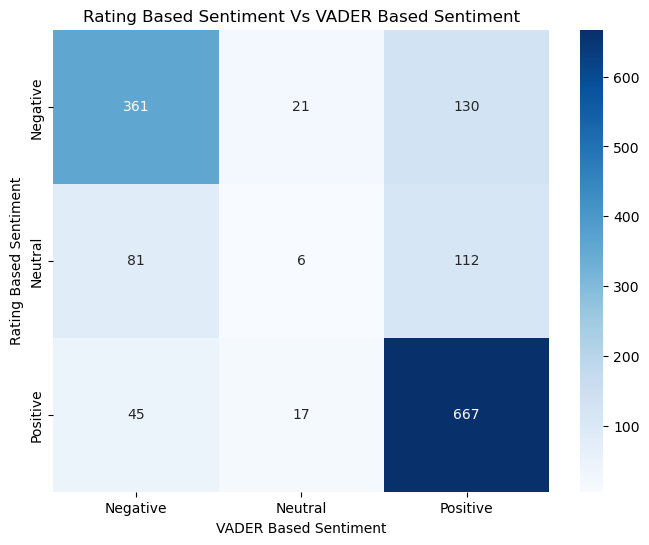

In [47]:
plt.figure(figsize=(8,6))
sns.heatmap(
    comparision,
    cmap='Blues',
    annot=True,
    fmt='d'
)
plt.title("Rating Based Sentiment Vs VADER Based Sentiment")

plt.xlabel("VADER Based Sentiment")
plt.ylabel("Rating Based Sentiment")
plt.show()

In [48]:
#initilize stop words and lemmatizer

In [49]:
stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()

In [50]:
#Create sentiment-aware cleaning function                            
negation_words = {
    "no",
    "not",
    "never",
    "neither",
    "nor",
    "cannot",
    "without"
}

In [51]:
#NLP text preprocessing

In [52]:
#NLP preprocessing function
def preprocess_text(text):

    # Convert to string
    text = str(text)

    # 1. Lowercasing
    text = text.lower()


    # 2. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+',' ',text )
    
    # 3. Remove @mentions
    
    text = re.sub( r'@\w+',' ',text)


    # 4. Handle hashtags
    
    text = re.sub(r'#(\w+)',r'\1',text)


    # 5. Remove HTML tags
    
    text = re.sub(r'<.*?>',' ',text)


    # 6. Remove numbers
    
    text = re.sub(r'\d+',' ',text)


    # 7. Remove punctuation

    text = text.translate(str.maketrans('','',string.punctuation))


    # 8. Normalize whitespace
    
    text = re.sub(r'\s+',' ',text).strip()

    # 9. Tokenization
    tokens = word_tokenize(text)

    # 10. Stopword removal
     # Remove stopwords but KEEP important negation words
    tokens = [
        word
        for word in tokens
        if word not in stop_words or word in negation_words
    ]

    # 11. Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    # 12. Remove very short words
    tokens = [
        word
        for word in tokens
        if len(word) > 1
    ]

    return tokens

In [53]:
#Apply NPL preprocessing to review_text
df['tokens'] = df['review_text'].apply(
    preprocess_text
)

In [54]:
df[['review_text', 'tokens']].head(10)

,review_text,tokens
0,Horrible product Very disappointed with the ov...,"[horrible, product, disappointed, overall, per..."
1,Camera quality is not like 48 megapixel Camera...,"[camera, quality, not, like, megapixel, camera..."
2,"Overall Got the mobile on the launch date,Batt...","[overall, got, mobile, launch, datebattery, mu..."
3,A big no from me 1. It doesn't work with 5.0GH...,"[big, no, doesnt, work, ghz, wifi, frequency, ..."
4,Put your money somewhere else Not worth buying...,"[put, money, somewhere, else, not, worth, buyi..."
5,Too much lagging and slow I will never purchas...,"[much, lagging, slow, never, purchase, samsung..."
6,Worst samsung mobile ever This is worst samsun...,"[worst, samsung, mobile, ever, worst, samsung,..."
7,कैसा दिखाते है उसका 10 % भी नही मोबाइल का कैमर...,"[कैसा, दिखाते, है, उसका, भी, नही, मोबाइल, का, ..."
8,Slow performance The phone hangs a lot and is ...,"[slow, performance, phone, hang, lot, slow, re..."
9,Don’t buy from Amazon. Very poor quality camer...,"[buy, amazon, poor, quality, camera, found, bo..."


In [55]:
#Create cleaned text from the tokens
df['cleaned_text'] = df['tokens'].apply(
    lambda x: ' '.join(x)
)

In [56]:
df[['review_text','cleaned_text']].head()

,review_text,cleaned_text
0,Horrible product Very disappointed with the ov...,horrible product disappointed overall performa...
1,Camera quality is not like 48 megapixel Camera...,camera quality not like megapixel camera quali...
2,"Overall Got the mobile on the launch date,Batt...",overall got mobile launch datebattery must app...
3,A big no from me 1. It doesn't work with 5.0GH...,big no doesnt work ghz wifi frequency ghz old ...
4,Put your money somewhere else Not worth buying...,put money somewhere else not worth buyingfault...


In [57]:
#Feature Engineering

In [58]:
#create the review length feature
df['review_length']=df['review_text'].apply(
    len
)

In [59]:
#create word count feature
df['word_count']=df['review_text'].apply(
    lambda x:len(str(x).split())
)

In [60]:
#create unique word feature
df['unique_word_count']=df['tokens'].apply(
    lambda x:len(set(x))
)

In [61]:
#create average word length feature
df['average_word_length']=df['tokens'].apply(
    lambda x:np.mean(
        [len(word) for word in x]) if len(x)>0 else 0
    )

In [62]:
#Create Sentence Count feature
def count_sentences(text):

    sentences = re.split(
        r'[.!?]+',
        str(text)
    )

    sentences = [
        sentence
        for sentence in sentences
        if sentence.strip()
    ]

    return len(sentences)


df['sentence_count'] = df['review_text'].apply(
    count_sentences
)

In [63]:
#create exclamation count feature
df['exclamation_count']=df['review_text'].apply(
    lambda x:str(x).count('!')
)

In [64]:
#create question count feature
df['question_count']=df['review_text'].apply(
    lambda x:str(x).count('?')
)

In [65]:
#create hashtag count feature
df['hashtag_count'] = df['review_text'].apply(
    lambda x: len(
        re.findall(
            r'#\w+',
            str(x)
        )
    )
)

In [66]:
# Add VADER sentiment scores as features

vader_scores = df['review_text'].apply(lambda x: sia.polarity_scores(str(x)))

df['vader_negative_score'] = vader_scores.apply(lambda score: score['neg'])
df['vader_neutral_score']  = vader_scores.apply(lambda score: score['neu'])
df['vader_positive_score'] = vader_scores.apply(lambda score: score['pos'])
df['vader_compound_score'] = vader_scores.apply(lambda score: score['compound'])

In [67]:
#Check all engineered features
feature_columns = [
    'review_length',
    'word_count',
    'unique_word_count',
    'average_word_length',
    'sentence_count',
    'exclamation_count',
    'question_count',
    'hashtag_count',
    'vader_negative_score',
    'vader_neutral_score',
    'vader_positive_score',
    'vader_compound_score'
]

df[feature_columns].head(10)

,review_length,word_count,unique_word_count,average_word_length,sentence_count,exclamation_count,question_count,hashtag_count,vader_negative_score,vader_neutral_score,vader_positive_score,vader_compound_score
0,76,10,6,8.666667,1,0,0,0,0.463,0.537,0.000,-0.7841
1,61,11,6,5.625000,1,0,0,0,0.319,0.681,0.000,-0.4956
2,411,67,34,6.513514,3,0,1,0,0.076,0.843,0.081,0.1027
3,394,72,35,4.897436,13,0,0,0,0.209,0.770,0.021,-0.9162
4,209,34,26,5.214286,4,0,0,0,0.235,0.765,0.000,-0.8033
5,128,23,11,5.400000,3,0,0,0,0.318,0.682,0.000,-0.7506
6,205,37,17,5.260870,4,0,0,0,0.193,0.753,0.054,-0.7845
7,167,37,23,3.787879,1,0,0,0,0.000,1.000,0.000,0.0000
8,105,19,8,6.300000,2,0,0,0,0.000,1.000,0.000,0.0000
9,210,32,21,5.875000,7,0,0,0,0.236,0.579,0.185,-0.6361


In [68]:
#check basic statistical measures of these features
df[feature_columns].describe()

,review_length,word_count,unique_word_count,average_word_length,sentence_count,exclamation_count,question_count,hashtag_count,vader_negative_score,vader_neutral_score,vader_positive_score,vader_compound_score
count,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000
mean,333.381944,58.257639,28.056944,5.759840,5.270139,0.233333,0.022917,0.009722,0.084256,0.753674,0.162062,0.264264
std,229.116704,39.896874,16.933244,1.504868,4.334030,1.219371,0.279287,0.223473,0.092287,0.116547,0.128670,0.695083
min,9.000000,2.000000,2.000000,3.263158,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.987100
25%,198.000000,34.000000,18.000000,5.362727,3.000000,0.000000,0.000000,0.000000,0.000000,0.686000,0.063750,-0.447675
50%,277.000000,49.000000,24.000000,5.687500,4.000000,0.000000,0.000000,0.000000,0.060000,0.765000,0.141000,0.610350
75%,395.000000,70.000000,34.000000,6.026681,7.000000,0.000000,0.000000,0.000000,0.131000,0.830000,0.236250,0.891000
max,2536.000000,391.000000,165.000000,57.333333,43.000000,23.000000,7.000000,8.000000,0.758000,1.000000,1.000000,0.995300


Text(0, 0.5, 'Frequency')

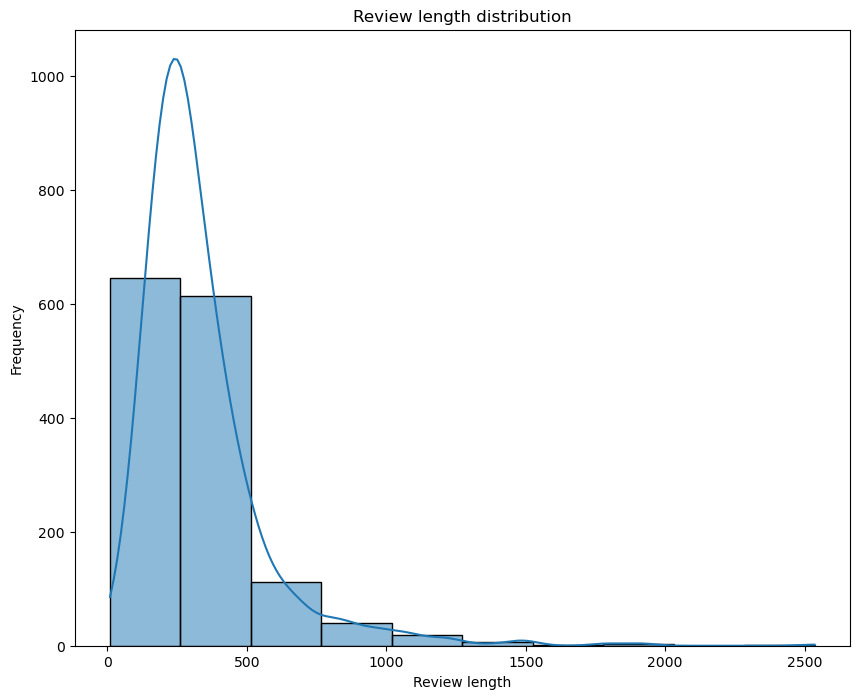

In [69]:
#Review length distribution
plt.figure(figsize=(10,8))

sns.histplot(
    data=df,
    x='review_length',
    bins=10,
    kde=True
)
plt.title('Review length distribution')
plt.xlabel('Review length')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

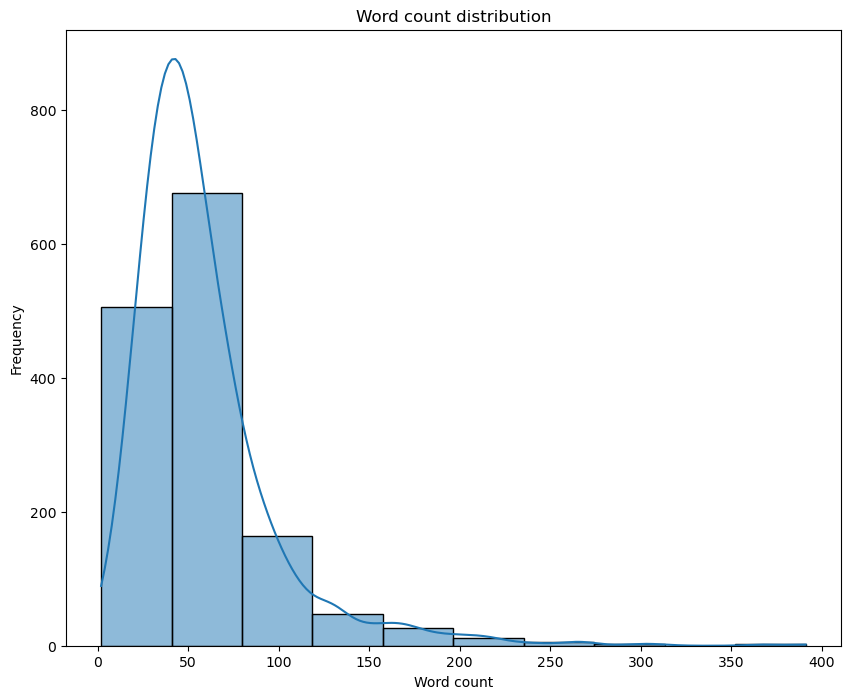

In [70]:
#word count distribution
#Review length distribution
plt.figure(figsize=(10,8))

sns.histplot(
    data=df,
    x='word_count',
    bins=10,
    kde=True
)
plt.title('Word count distribution')
plt.xlabel('Word count')
plt.ylabel('Frequency')

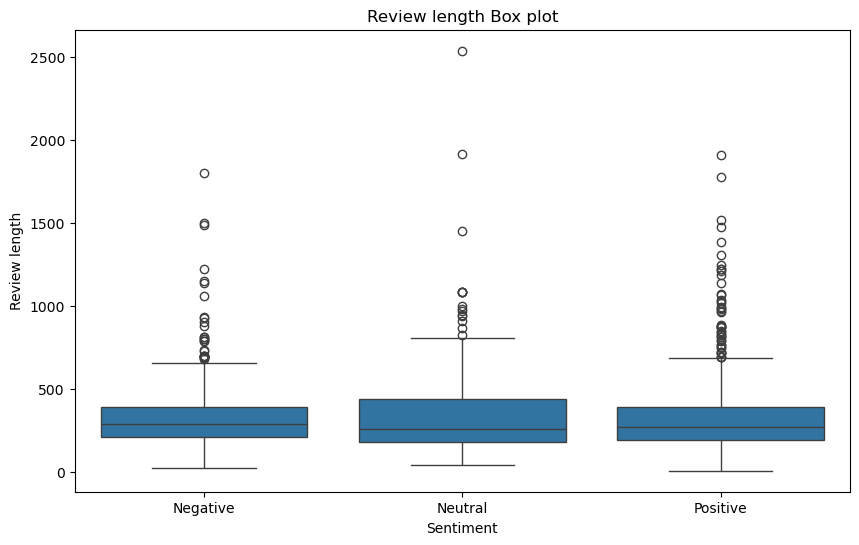

In [71]:
#Boxplot for review length
plt.figure(figsize=(10,6))

sns.boxplot(data=df,
            x='rating_sentiment',
            y='review_length',
)
plt.title('Review length Box plot')
plt.xlabel('Sentiment')
plt.ylabel('Review length')
plt.show()

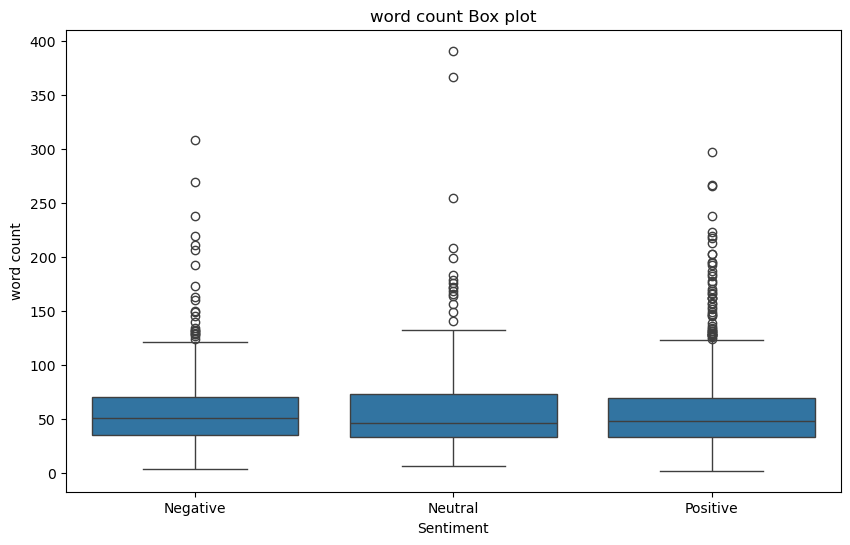

In [72]:
#Boxplot for word count
plt.figure(figsize=(10,6))

sns.boxplot(data=df,
            x='rating_sentiment',
            y='word_count',
)
plt.title('word count Box plot')
plt.xlabel('Sentiment')
plt.ylabel('word count')
plt.show()

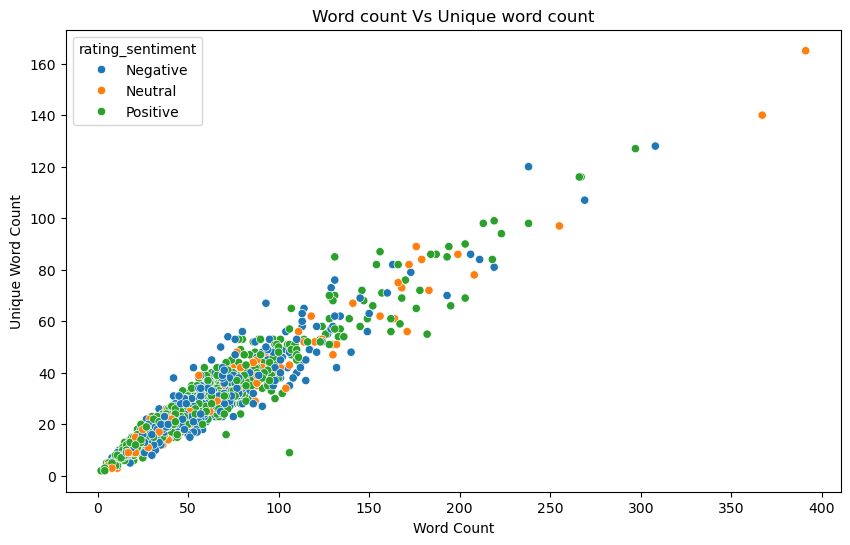

In [73]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='word_count', y='unique_word_count',hue='rating_sentiment', data=df)
plt.title('Word count Vs Unique word count')
plt.xlabel('Word Count')
plt.ylabel('Unique Word Count')
plt.show()

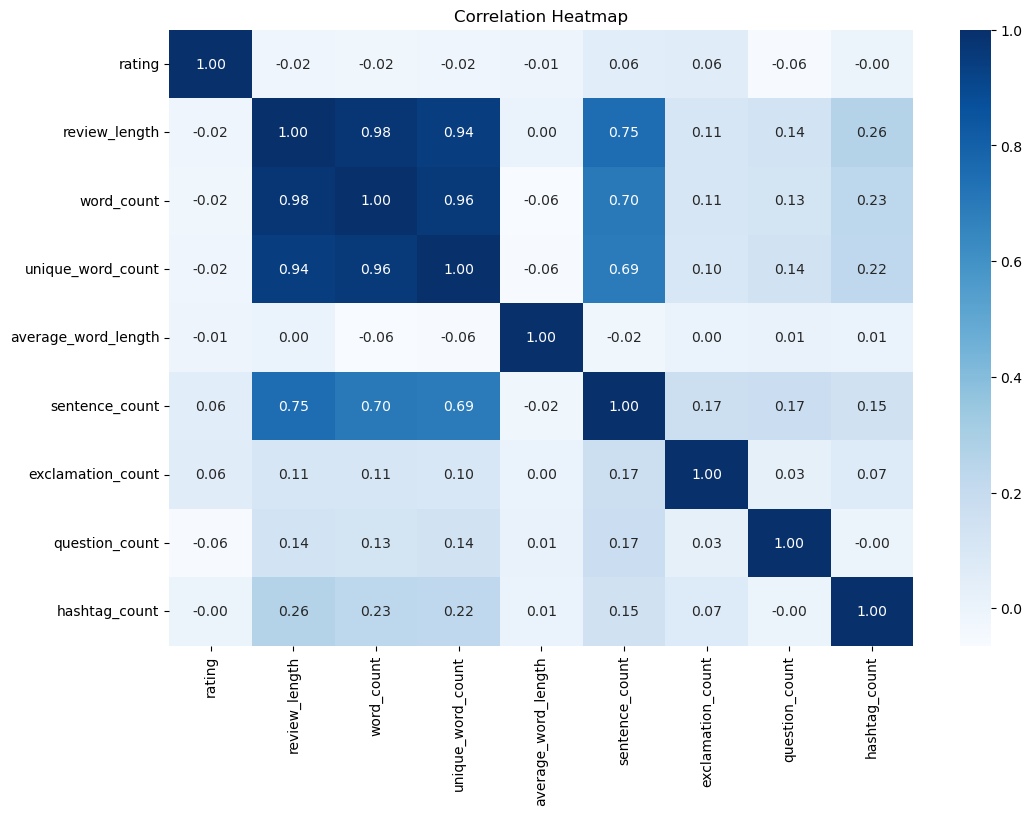

In [74]:
#Correlation heatmap
numeric_features = [
    'rating',
    'review_length',
    'word_count',
    'unique_word_count',
    'average_word_length',
    'sentence_count',
    'exclamation_count',
    'question_count',
    'hashtag_count'
]

plt.figure(figsize=(12,8))

sns.heatmap(
    df[numeric_features].corr(),
    annot=True,
    cmap='Blues',
    fmt='.2f')
plt.title("Correlation Heatmap")

plt.show()

In [75]:
#TF-IDF vectorization
tfidf=TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1,2),
    sublinear_tf=True
)

In [76]:
#Applying TF-IDF
tfidf_matrix=tfidf.fit_transform(
    df['cleaned_text'] )
print('tfidf matrix shape')
print(tfidf_matrix.shape)

tfidf matrix shape
(1440, 3000)


In [77]:
#Get the tfidf feature names
tfidf_features=tfidf.get_feature_names_out()

print('The number of TF-IDF features:')
print(len(tfidf_features))

print('The first 50 features')
print(tfidf_features[ :50])

The number of TF-IDF features:
3000
The first 50 features
['able' 'able hear' 'able return' 'absolutely' 'accept' 'acceptable'
 'access' 'according' 'according price' 'accurate' 'action' 'activity'
 'actual' 'actually' 'ad' 'adapter' 'adaptive' 'add' 'added' 'additional'
 'address' 'advertised' 'advertising' 'advice' 'advise' 'affordable'
 'affordable phone' 'affordable price' 'age' 'ago' 'agreed' 'ahead'
 'alarm' 'allow' 'allows' 'almost' 'almost month' 'along' 'already' 'also'
 'also camera' 'also good' 'also low' 'also nice' 'also not' 'alternative'
 'although' 'always' 'amazing' 'amazing battery']


In [78]:
#convert TF-IDF to dataframe
tfidf_df=pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_features
)

tfidf_df.head()

,able,able hear,able return,absolutely,accept,acceptable,access,according,according price,accurate,...,बत,बह,मर,यत,यह,रह,लग,लम,शन,सर
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [79]:
#Create model-ready dataset
engineered_features = df[
    [
        'review_length',
        'word_count',
        'unique_word_count',
        'average_word_length',
        'sentence_count',
        'exclamation_count',
        'question_count',
        'hashtag_count',
        'vader_negative_score',
        'vader_neutral_score',
        'vader_positive_score',
        'vader_compound_score'
    ]
].reset_index(drop=True)

In [80]:
#Now combine the TF-IDF with feature engineering features

model_df=pd.concat(
   [ tfidf_df,
    engineered_features
   ]
,axis=1
)

model_df.head()

,able,able hear,able return,absolutely,accept,acceptable,access,according,according price,accurate,...,unique_word_count,average_word_length,sentence_count,exclamation_count,question_count,hashtag_count,vader_negative_score,vader_neutral_score,vader_positive_score,vader_compound_score
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6,8.666667,1,0,0,0,0.463,0.537,0.000,-0.7841
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6,5.625000,1,0,0,0,0.319,0.681,0.000,-0.4956
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,34,6.513514,3,0,1,0,0.076,0.843,0.081,0.1027
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,35,4.897436,13,0,0,0,0.209,0.770,0.021,-0.9162
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,26,5.214286,4,0,0,0,0.235,0.765,0.000,-0.8033


In [81]:
#Add the target rating sentiment

model_df['sentiment']=(
    df['rating_sentiment'].values
)
model_df.head()

,able,able hear,able return,absolutely,accept,acceptable,access,according,according price,accurate,...,average_word_length,sentence_count,exclamation_count,question_count,hashtag_count,vader_negative_score,vader_neutral_score,vader_positive_score,vader_compound_score,sentiment
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.666667,1,0,0,0,0.463,0.537,0.000,-0.7841,Negative
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.625000,1,0,0,0,0.319,0.681,0.000,-0.4956,Neutral
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.513514,3,0,1,0,0.076,0.843,0.081,0.1027,Positive
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.897436,13,0,0,0,0.209,0.770,0.021,-0.9162,Negative
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.214286,4,0,0,0,0.235,0.765,0.000,-0.8033,Negative


In [82]:
print(df[["review_text", "cleaned_text", "rating_sentiment"]].head())

print("\nMissing values:")
print(df[["review_text", "rating_sentiment"]].isnull().sum())

print("\nSentiment distribution:")
print(df["rating_sentiment"].value_counts())

                                         review_text  \
0  Horrible product Very disappointed with the ov...   
1  Camera quality is not like 48 megapixel Camera...   
2  Overall Got the mobile on the launch date,Batt...   
3  A big no from me 1. It doesn't work with 5.0GH...   
4  Put your money somewhere else Not worth buying...   

                                        cleaned_text rating_sentiment  
0  horrible product disappointed overall performa...         Negative  
1  camera quality not like megapixel camera quali...          Neutral  
2  overall got mobile launch datebattery must app...         Positive  
3  big no doesnt work ghz wifi frequency ghz old ...         Negative  
4  put money somewhere else not worth buyingfault...         Negative  

Missing values:
review_text         0
rating_sentiment    0
dtype: int64

Sentiment distribution:
rating_sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64
